In [16]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt


con = duckdb.connect('../capillary.db')

df = con.execute("""
                SELECT id,
                    any_value(pid) as pid, 
                    any_value(value) as value,
                    list(c.comment_nr) as comment_nr,
                    any_value(sign) as sign,
                    any_value(age) as age,
                    any_value(set) as set,
                    any_value(haptoglobin) as haptoglobin,
                    any_value(analysis) as analysis,
                    any_value(protein_value) as protein_value
                FROM protein_data p
                LEFT JOIN comment_precences c 
                    ON p.id = c.row_id
                GROUP BY id
                 """).df()

con.close()

def to_severity(comments: list[int]):
    max_found = 0
    for comment in comments:
        result = map_severity(comment)
        if result > max_found:
            max_found = result
    return max_found
        

def map_severity(label: int) -> int:        
    severity = 0
    match label:
        case 40 |41 |42:
            severity = 1 #absolut 
        case 43 | 44 | 45:
            severity = 2 #relativ
        case _:
            severity = 0
    return severity



df['severity'] = df['comment_nr'].apply(to_severity)
df['relativ'] = (df['severity'] == 2).astype(int)
df = df[df['age']> 13]

In [17]:
severity_range = [0,1,2]

most_frequent = 0
position_weights = []

for i in severity_range:
    no_occurences = (df['severity'] == i).sum()
    print(f"Antal fall med klass {i}:{no_occurences}")
    if no_occurences > most_frequent:
        most_frequent=no_occurences

for i in severity_range:
    no_occurences = (df['severity'] == i).sum()
    position_weights.append( most_frequent/no_occurences) 


Antal fall med klass 0:166368
Antal fall med klass 1:3465
Antal fall med klass 2:905


In [18]:



test_rows = df[ df['set'] == 'test']
val_rows = df[ df['set'] == 'val' ]
train_rows = df[ df['set'] == 'train' ]

print(f"Antal fall relativ stegring i träningsdatan:{(train_rows['severity'] == 2).sum()}")
print(f"Antal fall utan stegring i träningsdatan:{(train_rows['severity'] == 0).sum()}")
print(f"Antal fall med relativ stegring i testdatan:{(test_rows['severity'] == 2).sum()}")
print(f"Antal fall utan stegring i testdatan:{(test_rows['severity'] == 0).sum()}")


Antal fall relativ stegring i träningsdatan:788
Antal fall utan stegring i träningsdatan:142473
Antal fall med relativ stegring i testdatan:79
Antal fall utan stegring i testdatan:16641


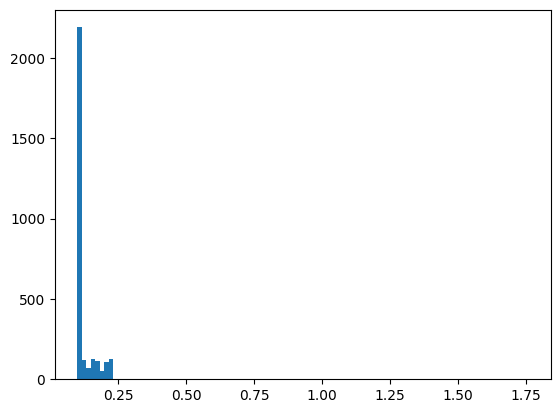

In [19]:
plt.figure()
plt.hist(train_rows[train_rows['severity'] == 1]['haptoglobin'],bins=100)
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_recall_curve
import joblib


X = np.vstack(train_rows['protein_value'].to_numpy())
y = np.array(train_rows['relativ'])
X = X[:,0:5]
scaler = StandardScaler()
X = scaler.fit_transform(X)

model = LogisticRegression(class_weight='balanced').fit(X, y)
joblib.dump(model,'haptoglobin.pkl')
joblib.dump(scaler, 'haptoglobin_scaler.pkl')

X_test = np.vstack(test_rows['protein_value'].to_numpy())
X_test = X_test[:,0:5]
y_test = np.array(test_rows['relativ'])
X_test = scaler.transform(X_test)

predictions = model.predict(X_test)
print(classification_report(y_test, predictions, target_names=['Negativ', 'Positiv']))

print(confusion_matrix(y_test, predictions))

probs = model.predict_proba(X_test)[:, 1]


print(model.coef_)
PROTEIN_LABELS = ['Albumin','Orosomukoid','Antitrypsin','Haptoglobin','CRP']
print(PROTEIN_LABELS)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 10 and the array at index 1 has size 9

## Resultat: 

Över 13 år: alla under 0,24 ska få kommentar 42